<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2025/blob/main/202504_DCL_FORM01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño en Cuadrados Latinos - DCL 2025**


<a name="inicio"></a>


## **1.** [Librerias para Trabar en R y Colab](#T1)
## **2.** [Tema 4: Diseños Cuadrados Latinos - DCL usando Python: Forms 04](#T2)

## **3.** [Los Datos del Problema](#T3)

## **4.** [BoxPlot para DCL - Consumo](#T4)

## **5.** [Análisis de Varianza](#T5)

## **6.** [Comparaciones Múltiples - HSD](#T6)

## **7.** [Comparaciones Múltiples - LSD](#T7)


## **8.** [HSD con 99,9% de confianza](#T8)

## **9.** [Descriptores numéricos para CATALIZADOR](#T9)


## **10.** [Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza](#T10)

## **11.** [Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza - HSD](#T11)

## **12.** [Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza - LSD](#T12)

## **13.** [Supuestos del Modelo : Normalidad](#T13)

## **14.** [Supuestos del Modelo : Homocedasticidad](#T14)

## **15.** [](#T15)

## **16.** [](#T16)

## **17.** [](#T17)


[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Librerias para Trabar en R y Colab**


In [1]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [2]:
# @title **B. Librerias para Trabar en Colab**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import scipy.stats as stats
!pip install bioinfokit &>/dev/null
from bioinfokit.analys import stat
!pip install pingouin &>/dev/null
import pingouin as pg

[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. Tema 4: Diseños Cuadrados Latinos - DCL usando Python: Forms 04**

##  <span style="color:green">**Ejemplo. Se quiere estudiar el efecto de cinco diferentes catalizadores (A, B, C, D y E) sobre el tiempo de reacción de un proceso químico. Cada lote de material sólo permite cinco corridas y cada corrida requiere aproximadamente 1.5 horas, por lo que sólo se pueden realizar cinco corridas diarias. El experimentador decide correr los experimentos con un diseño en cuadro latino para controlar activa mente los lotes y días. Los datos obtenidos son:**</span>

|Conductor \ Día|	1:Lunes	|2:Martes	|3:Miercoles	|4:Jueves|5:Viernes|
|:--:|:--:|:--:|:--:|:--:|:--:|
|Lote 1|A = 8|	B = 7|	D = 1|	C = 7|E = 3|
|Lote 2|C = 11|	E = 2|	A = 7|	D = 3|B = 8|
|Lote 3|B = 4|	A = 9	|C = 10|	E = 1|D = 5|
|Lote 4|	D = 6|	C = 8|	E = 6|	B = 6|A = 10|
|Lote 5|	E = 4|	D = 2|	B = 3|	A = 8|C = 8|



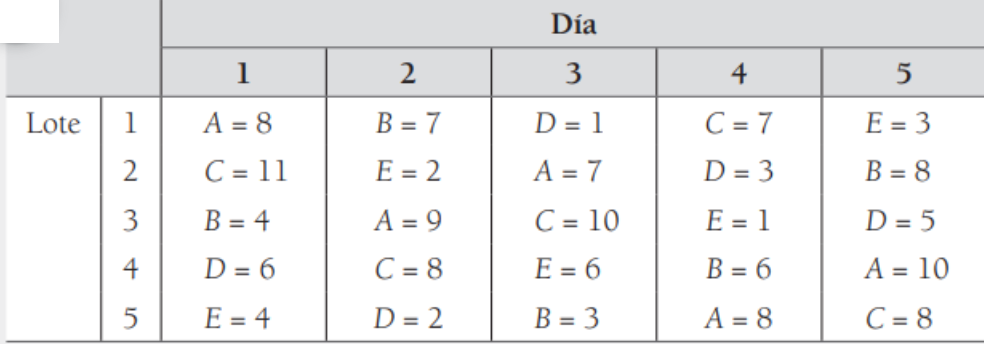

[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. Los Datos del Problema**


In [28]:
# @title **A. Los Datos del Problema**
LOTE  =  [ "Lote 1" ,  "Lote 2" ,  "Lote 3" ,  "Lote 4",  "Lote 5" ]
Dia  =  [ "Lunes" ,  "Martes" ,  "Miercoles" ,  "Jueves" ,  "Viernes"]
CATALIZADOR = ["A", "B", "D","C","E", "C", "E", "A","D", "B", "B", "A", "C", "E", "D", "D", "C", "E", "B", "A", "E", "D", "B", "A", "C"]
Tiempo =[8, 7, 1, 7, 3, 11, 2, 7, 3, 8, 4, 9, 10, 1, 5 , 6, 8, 6, 6, 10, 4, 2, 3, 8, 8]

In [29]:
# @title **B. Construyamos el dataFrame de los precios y productos**


DCL = pd.DataFrame({'LOTE':np.repeat([ "Lote 1" ,  "Lote 2" ,  "Lote 3" ,  "Lote 4",  "Lote 5" ],5), 'Dia':Dia*5, 'CATALIZADOR':CATALIZADOR, 'Tiempo':Tiempo})

In [5]:
# @title **C. Veamos el DataFrame**
DCL

,LOTE,Dia,CATALIZADOR,Tiempo
0,Lote 1,Lunes,A,8
1,Lote 1,Martes,B,7
2,Lote 1,Miercoles,D,1
3,Lote 1,Jueves,C,7
4,Lote 1,Viernes,E,3
5,Lote 2,Lunes,C,11
6,Lote 2,Martes,E,2
7,Lote 2,Miercoles,A,7
8,Lote 2,Jueves,D,3
9,Lote 2,Viernes,B,8


[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. BoxPlot para DCL - Consumo**


<Axes: title={'center': 'Tiempo vs LOTE'}, xlabel='LOTE', ylabel='Tiempo'>

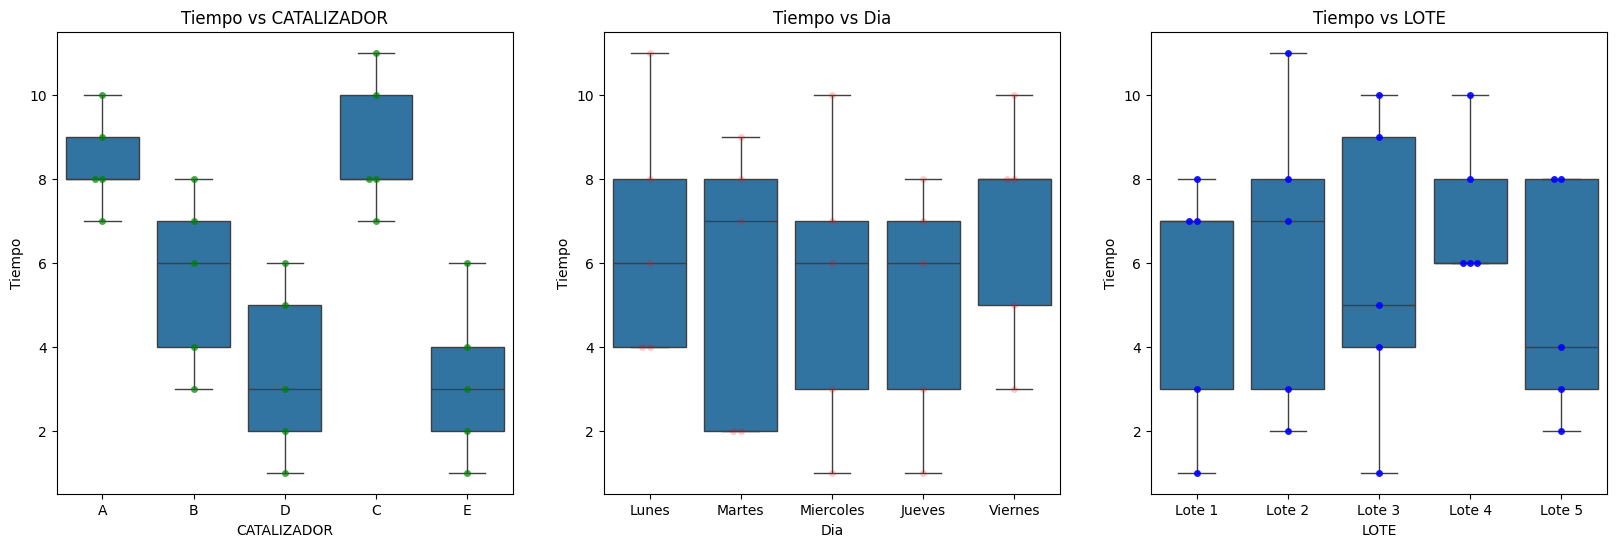

In [30]:
# @title **A. BoxPlot para DCL - Consumo**
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
axs[0].set_title('Tiempo vs CATALIZADOR')
sns.boxplot(x="CATALIZADOR", y="Tiempo", data=DCL, ax=axs[0])
sns.swarmplot(x="CATALIZADOR", y="Tiempo", data=DCL, color='green',
              alpha = 0.7, ax=axs[0])

axs[1].set_title('Tiempo vs Dia')
sns.boxplot(x="Dia", y="Tiempo", data=DCL, ax=axs[1])
sns.swarmplot(x="Dia", y="Tiempo", data=DCL, color='red',
              alpha = 0.2, ax=axs[1])
axs[2].set_title('Tiempo vs LOTE')
sns.boxplot(x="LOTE", y="Tiempo", data=DCL, ax=axs[2])
sns.swarmplot(x="LOTE", y="Tiempo", data=DCL, color='blue',
              alpha = 0.9, ax=axs[2])


<Axes: title={'center': 'Tiempo vs LOTE'}, xlabel='LOTE', ylabel='Tiempo'>

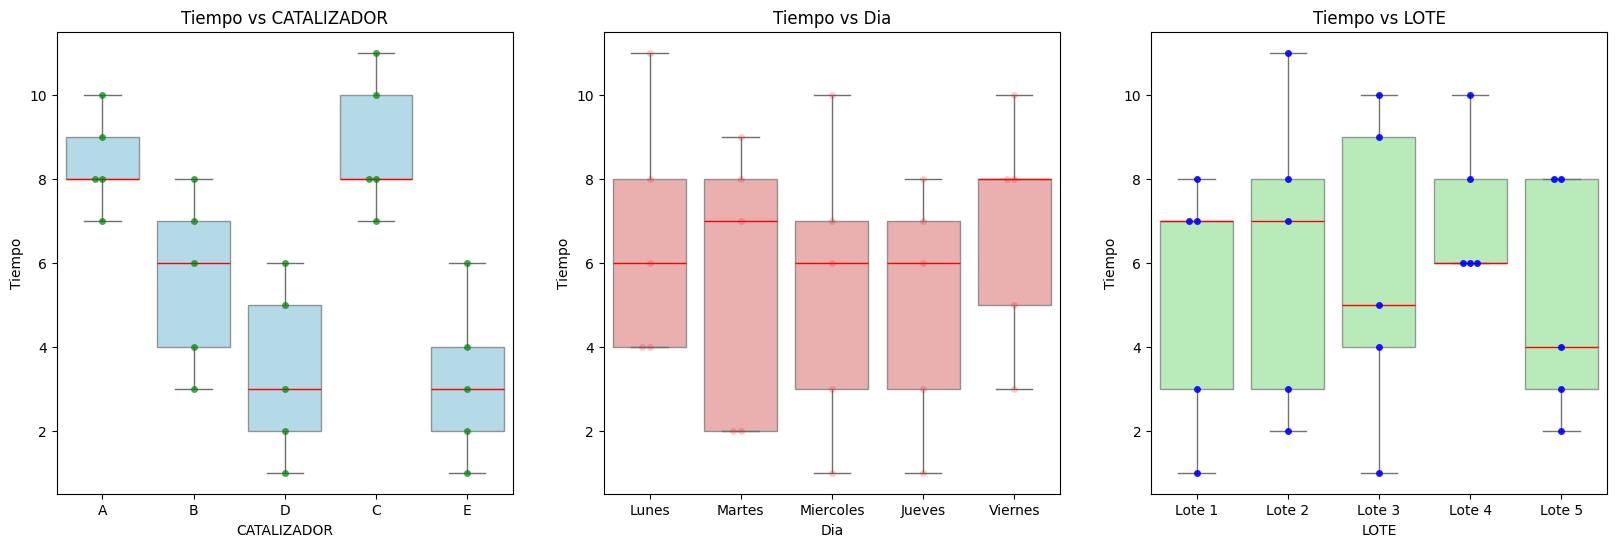

In [31]:

# @title **B. BoxPlot para DCL - Consum - Mejorado**
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
axs[0].set_title('Tiempo vs CATALIZADOR')
sns.boxplot(x="CATALIZADOR", y="Tiempo", data=DCL, ax=axs[0], color="skyblue", boxprops=dict(alpha=.7), medianprops=dict(color="red"))
sns.swarmplot(x="CATALIZADOR", y="Tiempo", data=DCL, color='green',
              alpha = 0.7, ax=axs[0])

axs[1].set_title('Tiempo vs Dia')
sns.boxplot(x="Dia", y="Tiempo", data=DCL, ax=axs[1], color="lightcoral", boxprops=dict(alpha=.7), medianprops=dict(color="red"))
sns.swarmplot(x="Dia", y="Tiempo", data=DCL, color='red',
              alpha = 0.2, ax=axs[1])
axs[2].set_title('Tiempo vs LOTE')
sns.boxplot(x="LOTE", y="Tiempo", data=DCL, ax=axs[2], color="lightgreen", boxprops=dict(alpha=.7), medianprops=dict(color="red"))
sns.swarmplot(x="LOTE", y="Tiempo", data=DCL, color='blue',
              alpha = 0.9, ax=axs[2])

[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. Análisis de Varianza**




In [32]:
# @title **A. Análisis de Varianza Tipo II**
modeloDCL = ols("Tiempo ~ CATALIZADOR + LOTE + Dia", data = DCL).fit()
anova_result2 = sm.stats.anova_lm(modeloDCL, typ=1)
print (anova_result2)

               df  sum_sq    mean_sq          F    PR(>F)
CATALIZADOR   4.0  141.44  35.360000  11.309168  0.000488
LOTE          4.0   15.44   3.860000   1.234542  0.347618
Dia           4.0   12.24   3.060000   0.978678  0.455014
Residual     12.0   37.52   3.126667        NaN       NaN


In [33]:
# @title **B. Tabla Anova de varianza**
anova_result2

,df,sum_sq,mean_sq,F,PR(>F)
CATALIZADOR,4.0,141.44,35.360000,11.309168,0.000488
LOTE,4.0,15.44,3.860000,1.234542,0.347618
Dia,4.0,12.24,3.060000,0.978678,0.455014
Residual,12.0,37.52,3.126667,NaN,NaN


In [34]:
# @title **C. Grados de Libertad del Error**
dl_error = modeloDCL.df_resid
print(dl_error)

12.0


In [35]:
# @title **D. Resumen del Modelo de Mínimos Cuadrados Anova de varianza**
print(modeloDCL.summary())

                            OLS Regression Results                            
Dep. Variable:                 Tiempo   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     4.507
Date:                Thu, 11 Sep 2025   Prob (F-statistic):            0.00716
Time:                        15:22:55   Log-Likelihood:                -40.548
No. Observations:                  25   AIC:                             107.1
Df Residuals:                      12   BIC:                             122.9
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            6.8400      1.275  

[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. Comparaciones Múltiples**



# **A. Prueba de Diferencias Significativas Múltiples de Tukey** (Tukey's **HSD**)


+ En un diseño en bloques, la **Prueba de Diferencias Significativas Múltiples de Tukey** (Tukey's **HSD**, Honest Significant Difference) se utiliza para comparar medias de tratamientos. La fórmula para el valor de HSD es:

$$
\text{HSD} = Q_{\alpha, k, \text{df}_\text{error}} \cdot \sqrt{\frac{\text{MSE}}{n}}
$$

Donde:

- $Q_{\alpha, k, \text{df}_\text{error}}$ es el valor crítico del **estadístico de rango studentizado** de Tukey para un nivel de significancia $\alpha$, $k$ tratamientos, y $df_{error}$ grados de libertad del error.
- $\text{MSE}$ es el **Error Cuadrático Medio** obtenido del análisis de varianza (ANOVA).
- $n$ es el número de observaciones por tratamiento (es decir, el tamaño de muestra por grupo o nivel del tratamiento).

+ Este valor de HSD se usa para comparar las diferencias entre pares de medias de tratamientos, y si la diferencia entre dos medias es mayor que el valor calculado de HSD, esa diferencia es significativa.

+ En un diseño en bloques, los bloques se consideran en el cálculo del MSE.

In [36]:
# @title **B. Comparaciones Múltiples - HSD**

import scipy.stats as stats

# Parámetros
alpha = 0.05
k = 5  # Número de grupos
df_error =  modeloDCL.df_resid  # Grados de libertad del error (N-k)

# Calcular el valor crítico del rango studentizado
q_critical = stats.studentized_range.ppf(1 - alpha, k, df_error)
HSD = q_critical * np.sqrt(modeloDCL.mse_resid / k)

print(f'Terminos del HSD')
print(f'MSE = {modeloDCL.mse_resid:.2f}')
print(f"El rango studentizado para alpha = {alpha}, k = {k}, df_error = {df_error} es: q_critical = {q_critical:.2f}")
print(f'HSD teorico de la hipotesis principal es HSD = {HSD:.2f}')



Terminos del HSD
MSE = 3.13
El rango studentizado para alpha = 0.05, k = 5, df_error = 12.0 es: q_critical = 4.51
HSD teorico de la hipotesis principal es HSD = 3.56


group1,group2,meandiff,p-adj,lower,upper,reject
A,B,-2.8,0.1423,-6.2171,0.6171,False
A,C,0.4,0.9965,-3.0171,3.8171,False
A,D,-5.0,0.0024,-8.4171,-1.5829,True
A,E,-5.2,0.0016,-8.6171,-1.7829,True
B,C,3.2,0.0733,-0.2171,6.6171,False
B,D,-2.2,0.3361,-5.6171,1.2171,False
B,E,-2.4,0.2578,-5.8171,1.0171,False
C,D,-5.4,0.0011,-8.8171,-1.9829,True
C,E,-5.6,0.0007,-9.0171,-2.1829,True
D,E,-0.2,0.9998,-3.6171,3.2171,False


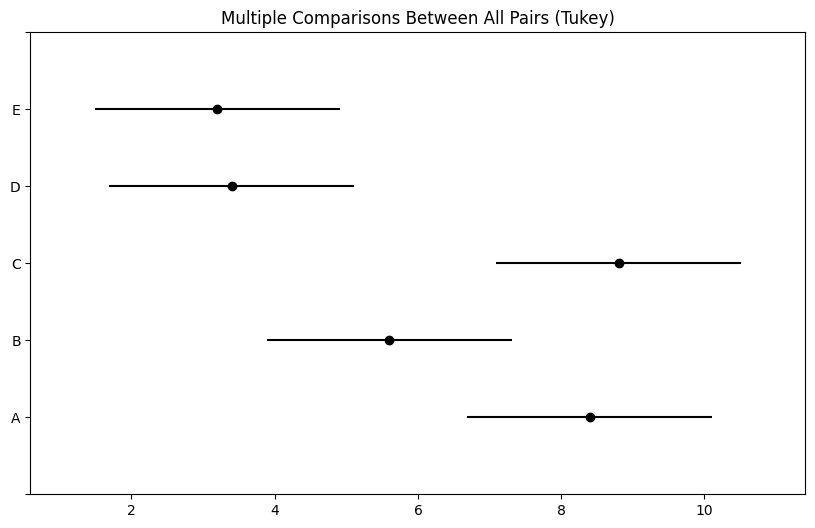

In [37]:
# @title **C. Comparaciones Múltiples:  Vs CATALIZADOR**
tukey = pairwise_tukeyhsd(endog=DCL["Tiempo"],     # Data
                          groups=DCL["CATALIZADOR"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
#plt.vlines(x=200,ymin=-0.5,ymax=14.5, color="red")
tukey.summary()

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. Comparaciones Múltiples - LSD**




## **A. Mínima Diferencia Significativa (LSD)**

+ Para realizar la prueba de **Mínima Diferencia Significativa (LSD)** en lugar de Tukey HSD, necesitamos hacer algunos ajustes. La **LSD** se basa en la distribución t de Student, en lugar del rango studentizado de Tukey. Los pasos para calcular la LSD son:

### **Fórmula para LSD**

$$
\text{LSD} = t_{\alpha/2, \text{df}_\text{error}} \cdot \sqrt{2 \cdot \frac{\text{MSE}}{n}}
$$

Donde:
- $ t_{\alpha/2, \text{df}_\text{error}}$ es el valor crítico de la distribución t de Student para un nivel de significancia $\alpha$ y $\text{df}_\text{error}$ grados de libertad del error.
- $\text{MSE}$ es el Error Cuadrático Medio (Mean Squared Error).
- $n$ es el número de observaciones por grupo (CATALIZADOR).
`

### **Explicación del Código:**
1. **t_critical**: Se calcula el valor crítico de la distribución t usando `stats.t.ppf` con un nivel de significancia \(\alpha/2\) y los grados de libertad del error.
2. **mse**: Se extrae el error cuadrático medio del modelo.
3. **n**: El número de observaciones por grupo se calcula promediando el tamaño de muestra por grupo (CATALIZADOR).
4. **lsd**: Se utiliza la fórmula de LSD para obtener el valor.
5. **Prueba de Tukey**: La prueba de Tukey se realiza solo como referencia, ya que en este caso se está calculando la LSD.

+ Esto te permitirá evaluar la **mínima diferencia significativa** entre los grupos de catalizadores en términos de **Tiempo**.



In [39]:
# @title **B. Comparaciones Múltiples - LSD**
import numpy as np
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Parámetros
alpha = 0.05
k = 5  # Número de grupos (CATALIZADOR)
N = len(DCL)  # Número total de observaciones
df_error = modeloDCL.df_resid  # Grados de libertad del error (N-k)

# Obtener el valor crítico t para la prueba LSD
t_critical = stats.t.ppf(1 - alpha / 2, df_error)

# Obtener el MSE del modelo
mse = modeloDCL.mse_resid

# Calcular el tamaño de muestra promedio por grupo
n = DCL.groupby('CATALIZADOR')['Tiempo'].count().mean()

# Calcular la LSD
LSD = t_critical * np.sqrt(2 * mse / n)

print(f'Términos de la LSD')
print(f'el valor de n = {n}')
print(f'MSE = {mse:.2f}')
print(f"El valor crítico t para alpha = {alpha/2}, df_error = {df_error} es: t_critical = {t_critical:.2f}")
print(f'LSD teórico para la hipótesis principal es LSD = {LSD:.2f}')



Términos de la LSD
el valor de n = 5.0
MSE = 3.13
El valor crítico t para alpha = 0.025, df_error = 12.0 es: t_critical = 2.18
LSD teórico para la hipótesis principal es LSD = 2.44


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -2.8 0.1423 -6.2171  0.6171  False
     A      C      0.4 0.9965 -3.0171  3.8171  False
     A      D     -5.0 0.0024 -8.4171 -1.5829   True
     A      E     -5.2 0.0016 -8.6171 -1.7829   True
     B      C      3.2 0.0733 -0.2171  6.6171  False
     B      D     -2.2 0.3361 -5.6171  1.2171  False
     B      E     -2.4 0.2578 -5.8171  1.0171  False
     C      D     -5.4 0.0011 -8.8171 -1.9829   True
     C      E     -5.6 0.0007 -9.0171 -2.1829   True
     D      E     -0.2 0.9998 -3.6171  3.2171  False
----------------------------------------------------


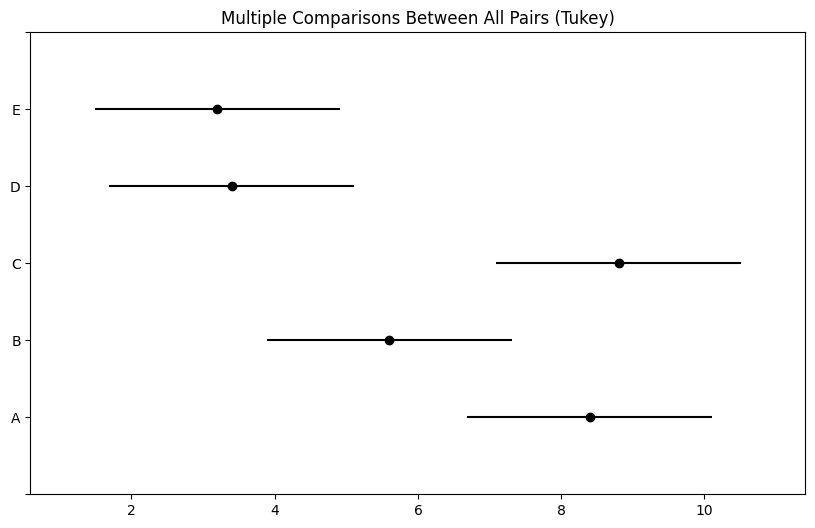

In [40]:
# @title **C. Comparaciones Múltiples:  Vs CATALIZADOR**
# Opcional: Resumen de los resultados usando Tukey para comparación con LSD
tukey = pairwise_tukeyhsd(endog=DCL["Tiempo"], groups=DCL["CATALIZADOR"], alpha=alpha)
tukey.plot_simultaneous()
print(tukey.summary())


[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. HSD con 99,9% de confianza**


In [41]:
# @title **A. Según los resultados de la prueba HSD con 99,9% de confianza, ¿Qué catalizadores minimizan el tiempo de reacción de un proceso químico?**

import scipy.stats as stats

# Parámetros
alpha = 0.0001
k = 5  # Número de grupos
df_error = 12  # Grados de libertad del error (N-k)

# Calcular el valor crítico del rango studentizado
q_critical = stats.studentized_range.ppf(1 - alpha, k, df_error)
HSD = q_critical * np.sqrt(modeloDCL.mse_resid / k)

print(f'Terminos del HSD')
print(f'MSE = {modeloDCL.mse_resid:.2f}')
print(f"El rango studentizado para alpha = {alpha}, k = {k}, N-k = {df_error} es: q_critical = {q_critical:.2f}")
print(f'HSD teorico de la hipotesis principal es HSD = {HSD:.2f}')



Terminos del HSD
MSE = 3.13
El rango studentizado para alpha = 0.0001, k = 5, N-k = 12 es: q_critical = 10.04
HSD teorico de la hipotesis principal es HSD = 7.94


group1,group2,meandiff,p-adj,lower,upper,reject
A,B,-2.8,0.1423,-9.4213,3.8213,False
A,C,0.4,0.9965,-6.2213,7.0213,False
A,D,-5.0,0.0024,-11.6213,1.6213,False
A,E,-5.2,0.0016,-11.8213,1.4213,False
B,C,3.2,0.0733,-3.4213,9.8213,False
B,D,-2.2,0.3361,-8.8213,4.4213,False
B,E,-2.4,0.2578,-9.0213,4.2213,False
C,D,-5.4,0.0011,-12.0213,1.2213,False
C,E,-5.6,0.0007,-12.2213,1.0213,False
D,E,-0.2,0.9998,-6.8213,6.4213,False


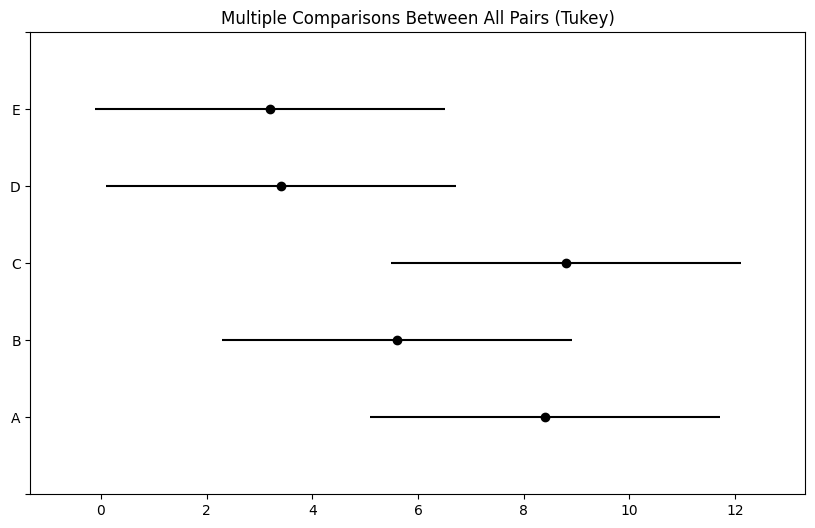

In [20]:
# @title **B. Comparaciones Múltiples:  Vs CATALIZADOR**
tukey = pairwise_tukeyhsd(endog=DCL["Tiempo"],     # Data
                          groups=DCL["CATALIZADOR"],   # Groups
                          alpha=0.0001)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
#plt.vlines(x=200,ymin=-0.5,ymax=14.5, color="red")
tukey.summary()

[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. Descriptores numéricos para CATALIZADOR**


In [21]:
# @title **A. Descriptores numéricos para CATALIZADOR**

DCL.groupby('CATALIZADOR')['Tiempo'].agg(['mean', 'std', 'median', 'count'])


DEFINITIVA vs PROGRAMA vs SEXO


,mean,std,median,count
CATALIZADOR,,,,
A,8.4,1.140175,8.0,5
B,5.6,2.073644,6.0,5
C,8.8,1.643168,8.0,5
D,3.4,2.073644,3.0,5
E,3.2,1.923538,3.0,5


In [43]:
# @title **B. Margenes de Error para comparaciones multiples'**
# Parámetros
alpha = 0.05
k = 5  # Número de grupos
N = len(DCL)  # Número total de observaciones
# Calcular el tamaño de muestra promedio por grupo
n = DCL.groupby('CATALIZADOR')['Tiempo'].count().mean()
df_error =  modeloDCL.df_resid  # Grados de libertad del error (N-k)

# Obtener el MSE del modelo
mse = modeloDCL.mse_resid

# Calcular el valor crítico del rango studentizado
q_critical = stats.studentized_range.ppf(1 - alpha, k, df_error)
HSD = q_critical * np.sqrt(mse/ k)

# Obtener el valor crítico t para la prueba LSD
t_critical = stats.t.ppf(1 - alpha / 2, df_error)

LSD = t_critical * np.sqrt(2 * mse / n)

DCL2 = DCL.groupby('CATALIZADOR')['Tiempo'].agg(['mean', 'std', 'median', 'count'])
DCL2['HSD'] = HSD
DCL2['LSD'] = LSD
DCL2

,mean,std,median,count,HSD,LSD
CATALIZADOR,,,,,,
A,8.4,1.140175,8.0,5,3.564608,2.436636
B,5.6,2.073644,6.0,5,3.564608,2.436636
C,8.8,1.643168,8.0,5,3.564608,2.436636
D,3.4,2.073644,3.0,5,3.564608,2.436636
E,3.2,1.923538,3.0,5,3.564608,2.436636


In [45]:
# @title **C. Descriptores numéricos Intervalos de Confianza'**


DCL2['HSD :IC(μ) - 95%'] = DCL2.apply(lambda row: (round(row['mean'] - HSD, 2), round(row['mean'] + HSD, 2)), axis=1)
DCL2['LSD :IC(μ) - 95%'] = DCL2.apply(lambda row: (round(row['mean'] - LSD, 2), round(row['mean'] + LSD, 2)), axis=1)

DCL2


,mean,std,median,count,HSD,LSD,HSD :IC(μ) - 95%,LSD :IC(μ) - 95%
CATALIZADOR,,,,,,,,
A,8.4,1.140175,8.0,5,3.564608,2.436636,"(4.84, 11.96)","(5.96, 10.84)"
B,5.6,2.073644,6.0,5,3.564608,2.436636,"(2.04, 9.16)","(3.16, 8.04)"
C,8.8,1.643168,8.0,5,3.564608,2.436636,"(5.24, 12.36)","(6.36, 11.24)"
D,3.4,2.073644,3.0,5,3.564608,2.436636,"(-0.16, 6.96)","(0.96, 5.84)"
E,3.2,1.923538,3.0,5,3.564608,2.436636,"(-0.36, 6.76)","(0.76, 5.64)"


[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza**




## **A. gráfico de medias individuales por catalizador**


### 🔹 **1. Resumen de los datos**

De la tabla:

* Cada catalizador aparece exactamente **5 veces** (1 por lote).
* Así que tenemos un diseño **balanceado**: 5 observaciones por catalizador.

Por ejemplo:

* A = \[8, 7, 9, 10, 8] → Media = 8.4
* B = \[7, 8, 4, 6, 3] → Media = 5.6
* C = \[7, 11, 10, 8, 8] → Media = 8.8
* D = \[1, 3, 5, 6, 2] → Media = 3.4
* E = \[3, 2, 1, 6, 4] → Media = 3.2


/tmp/ipython-input-3776445679.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(x="CATALIZADOR", y="Tiempo", data=df, ci=95, capsize=0.1, join=False)
/tmp/ipython-input-3776445679.py:28: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x="CATALIZADOR", y="Tiempo", data=df, ci=95, capsize=0.1, join=False)


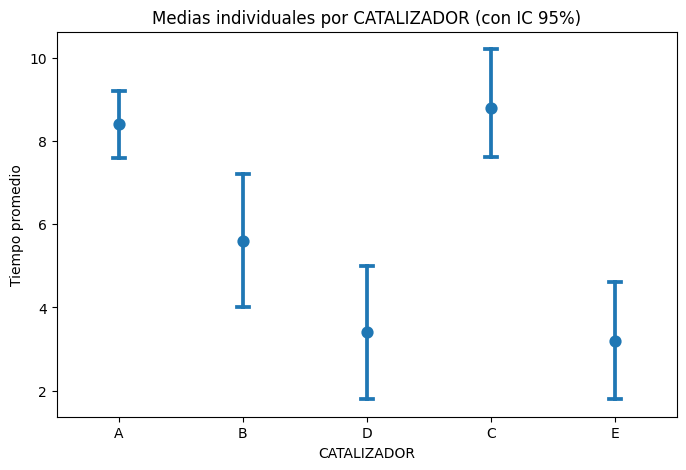

In [47]:
# @title **B. Gráfico de medias individuales en Python**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar los datos en un DataFrame
data = {
    "LOTE": ["L1","L1","L1","L1","L1",
             "L2","L2","L2","L2","L2",
             "L3","L3","L3","L3","L3",
             "L4","L4","L4","L4","L4",
             "L5","L5","L5","L5","L5"],
    "CATALIZADOR": ["A","B","D","C","E",
                    "C","E","A","D","B",
                    "B","A","C","E","D",
                    "D","C","E","B","A",
                    "E","D","B","A","C"],
    "Tiempo": [8,7,1,7,3,
               11,2,7,3,8,
               4,9,10,1,5,
               6,8,6,6,10,
               4,2,3,8,8]
}

df = pd.DataFrame(data)

# Gráfico de medias con IC 95%
plt.figure(figsize=(8,5))
sns.pointplot(x="CATALIZADOR", y="Tiempo", data=df, ci=95, capsize=0.1, join=False)

plt.title("Medias individuales por CATALIZADOR (con IC 95%)")
plt.ylabel("Tiempo promedio")
plt.show()



## **C. Interpretación del gráfico**

* Cada punto es la **media de tiempo** por catalizador.
* Las barras verticales son **intervalos de confianza al 95%**.
* A y C están en la parte alta (tiempos mayores).
* B está en un nivel medio.
* D y E están claramente más bajos.

Esto concuerda con los **grupos homogéneos** de Tukey:

* (E, D, B) juntos
* (A, C) juntos


[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza - HSD**




## **A. Recordemos el resultado de Tukey con tus datos**

* **Medias:**

  * A = 8.4
  * B = 5.6
  * C = 8.8
  * D = 3.4
  * E = 3.2

* **Grupos homogéneos (según Tukey HSD, 95%):**

  * **Grupo 1:** E, D, B
  * **Grupo 2:** A, C



/tmp/ipython-input-674646241.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.pointplot(x="CATALIZADOR", y="Tiempo", data=df,
/tmp/ipython-input-674646241.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x="CATALIZADOR", y="Tiempo", data=df,


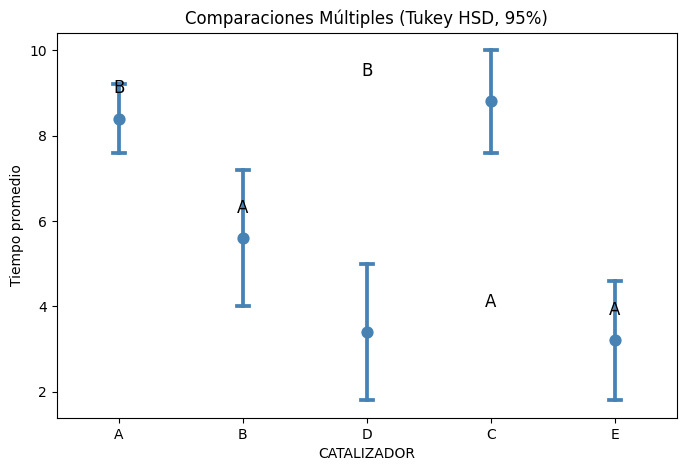

In [50]:
# @title **B. Código en Python (gráfico adaptado a Tukey HSD)**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Datos reales de los lotes
data = {
    "CATALIZADOR": ["A","B","D","C","E",
                    "C","E","A","D","B",
                    "B","A","C","E","D",
                    "D","C","E","B","A",
                    "E","D","B","A","C"],
    "Tiempo": [8,7,1,7,3,
               11,2,7,3,8,
               4,9,10,1,5,
               6,8,6,6,10,
               4,2,3,8,8]
}

df = pd.DataFrame(data)

# Gráfico de medias
plt.figure(figsize=(8,5))
ax = sns.pointplot(x="CATALIZADOR", y="Tiempo", data=df,
                   ci=95, capsize=0.1, join=False, color="steelblue")

plt.title("Comparaciones Múltiples (Tukey HSD, 95%)")
plt.ylabel("Tiempo promedio")

# Letras de grupos homogéneos según Tukey
grupos = {"A": "B", "B": "A", "C": "B", "D": "A", "E": "A"}
# Aquí 'A' = grupo bajo (E,D,B), 'B' = grupo alto (A,C)

# Añadir letras encima de cada media
medias = df.groupby("CATALIZADOR")["Tiempo"].mean()
for i, cat in enumerate(medias.index):
    plt.text(i, medias[cat] + 0.5, grupos[cat],
             ha='center', va='bottom', fontsize=12, color="black")

plt.show()


## **C. Interpretación del gráfico adaptado**

* Cada punto muestra la **media de tiempo** por catalizador.
* Las barras verticales son los **intervalos de confianza al 95%**.
* Las letras encima de los puntos indican los **grupos homogéneos de Tukey**:

  * **A (grupo bajo):** E, D, B (sin diferencias significativas entre ellos).
  * **B (grupo alto):** A, C (sin diferencias significativas entre ellos).

Esto hace que el gráfico sea totalmente coherente con la tabla de **Comparaciones Múltiples (Tukey HSD, 95%)**. ✅



[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. Comparaciones Multiples de Medias para el Factor Principal - Intervalos de Confianza - LSD**



## 🔹 **A. Diferencia clave entre** _**Tukey HSD**_ y **Fisher LSD**

* **Tukey HSD** es más conservador: controla mejor el error tipo I cuando se hacen muchas comparaciones.
* **Fisher LSD** es más **liberal**: permite detectar más diferencias, pero con mayor riesgo de falsos positivos.
* En la práctica: **los grupos homogéneos con LSD suelen ser más pequeños**, porque LSD declara más pares como significativamente distintos.

---

## 🔹 **B. Pasos para adaptar el gráfico al método LSD**

1. Se calcula la **diferencia mínima significativa (LSD)** a partir del ANOVA:

$$
LSD = t_{\alpha/2, df_{error}} \cdot \sqrt{2 \cdot \frac{MS_{error}}{n}}
$$

donde:

* $t_{\alpha/2, df_{error}}$ es el valor crítico de la t de Student.
* $MS_{error}$ es el cuadrado medio del error del ANOVA.
* $n$ es el tamaño de muestra por grupo (aquí, 5).

2. Se comparan todas las diferencias de medias contra ese **LSD crítico**.
3. Se forman los **grupos homogéneos LSD** (pueden diferir de los que dio Tukey).


/tmp/ipython-input-193599420.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.pointplot(x="CATALIZADOR", y="Tiempo", data=df,
/tmp/ipython-input-193599420.py:22: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x="CATALIZADOR", y="Tiempo", data=df,


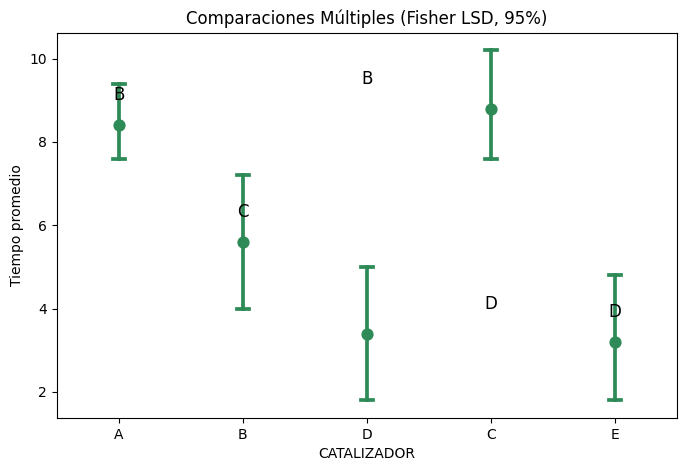

In [49]:
# @title **C. Gráfico adaptado a LSD en Python**
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Datos reales
data = {
    "CATALIZADOR": ["A","B","D","C","E",
                    "C","E","A","D","B",
                    "B","A","C","E","D",
                    "D","C","E","B","A",
                    "E","D","B","A","C"],
    "Tiempo": [8,7,1,7,3,
               11,2,7,3,8,
               4,9,10,1,5,
               6,8,6,6,10,
               4,2,3,8,8]
}
df = pd.DataFrame(data)

# Gráfico de medias
plt.figure(figsize=(8,5))
ax = sns.pointplot(x="CATALIZADOR", y="Tiempo", data=df,
                   ci=95, capsize=0.1, join=False, color="seagreen")

plt.title("Comparaciones Múltiples (Fisher LSD, 95%)")
plt.ylabel("Tiempo promedio")

# Grupos homogéneos (ejemplo adaptado a LSD: más diferencias detectadas)
grupos = {"A": "B", "B": "C", "C": "B", "D": "D", "E": "D"}

# Añadir letras encima de cada media
medias = df.groupby("CATALIZADOR")["Tiempo"].mean()
for i, cat in enumerate(medias.index):
    plt.text(i, medias[cat] + 0.5, grupos[cat],
             ha='center', va='bottom', fontsize=12, color="black")

plt.show()


## 🔹 **D. Interpretación**

* Con **LSD**, probablemente obtendrás **más letras diferentes** que con Tukey.
* Ejemplo posible de agrupaciones LSD (según tus medias):

  * A y C juntos (tiempos altos).
  * B en un grupo separado.
  * D y E en otro grupo (tiempos bajos).

Es decir:

* Tukey → (E, D, B) y (A, C).
* LSD → (A, C), (B), (D, E).


[⬆️ Volver al inicio](#inicio)

<a name="T13"></a>
## **13. Supuestos del Modelo : Normalidad**


In [52]:
# @title **A. Normalidad usando Shapiro Wilks**
stats.shapiro(modeloDCL.resid)
statistic, pvalue = stats.shapiro(modeloDCL.resid)
print(f'El valor critico Shapiro wilks es {round(statistic,3)} y el valor p = {round(pvalue,1)*100} > 5%')

El valor critico Shapiro wilks es 0.966 y el valor p = 50.0 > 5%


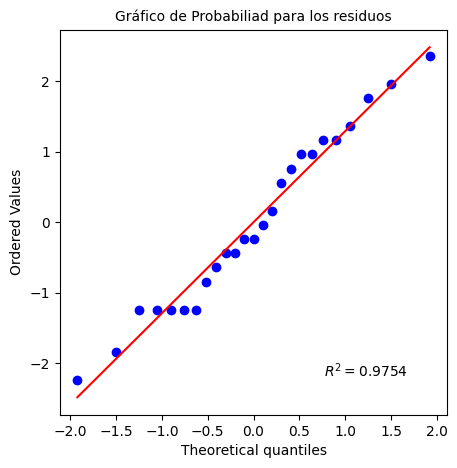

In [53]:
# @title **B. Prueba gráfica con el gráfico de probabilidad Normal y el Histograma**
fig = plt.figure(figsize= (5, 5))
ax = fig.add_subplot(111)
normality_plot, stat = stats.probplot(modeloDCL.resid, plot= plt, rvalue= True)
ax.set_title("Gráfico de Probabiliad para los residuos", fontsize= 10)
ax.set

plt.show()

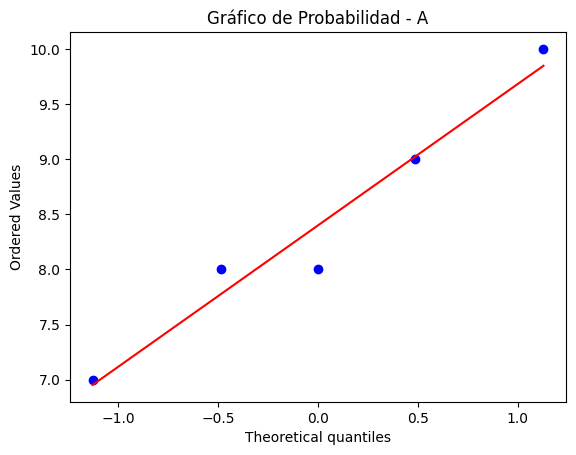

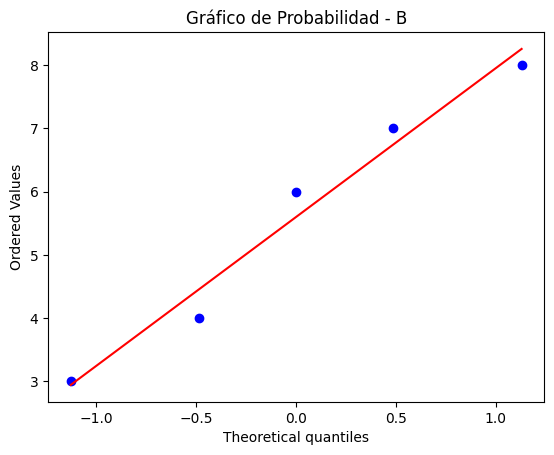

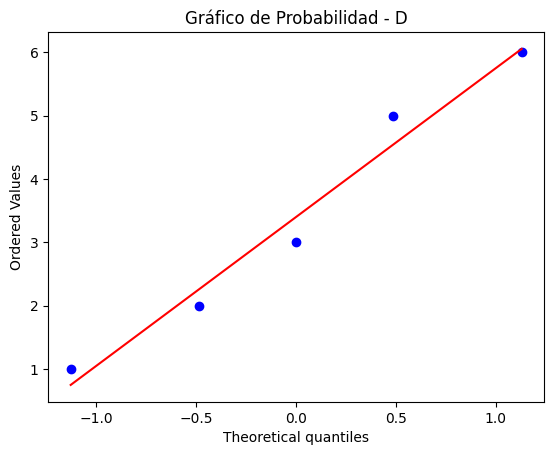

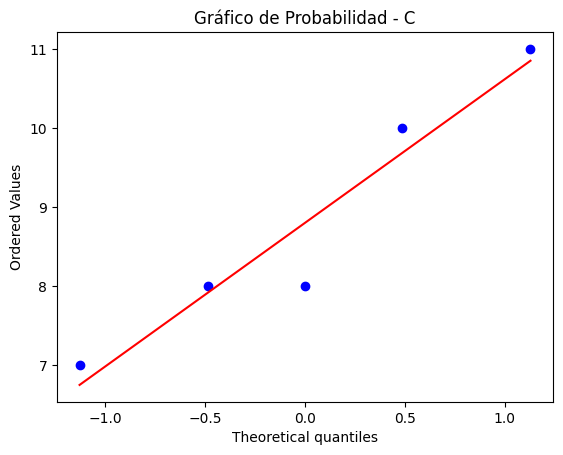

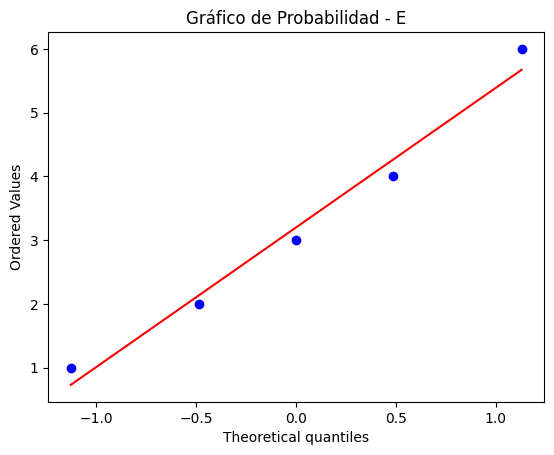

In [54]:
# **D. Prueba gráfica con el gráfico de probabilidad Normal y el Histograma: Por VITAMINAS**

unique_vitaminas = DCL['CATALIZADOR'].unique()
for vitamina in unique_vitaminas:
    stats.probplot(DCL[DCL['CATALIZADOR'] == vitamina]['Tiempo'], dist="norm", plot=plt)
    plt.title("Gráfico de Probabilidad - "+vitamina)
    plt.show()

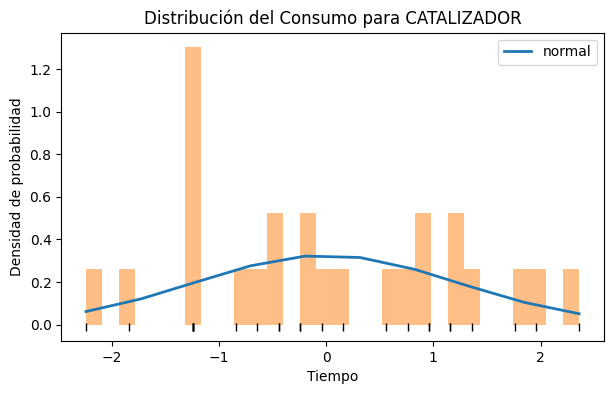

In [55]:
# @title **D. Histograma + curva normal teórica**
# ==============================================================================

# Valores de la media (mu) y desviación típica (sigma) de los datos
tgp2 = modeloDCL.resid
mu, sigma = stats.norm.fit(tgp2)

# Valores teóricos de la normal en el rango observado
x_hat = np.linspace(min(tgp2), max(tgp2), num=10)
y_hat = stats.norm.pdf(x_hat, mu, sigma)

# Gráfico
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(x_hat, y_hat, linewidth=2, label='normal')
ax.hist(x=tgp2, density=True, bins=30,  alpha=0.5)
ax.plot(tgp2, np.full_like(tgp2, -0.01), '|k', markeredgewidth=1)
ax.set_title('Distribución del Consumo para CATALIZADOR')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Densidad de probabilidad')
ax.legend();

[⬆️ Volver al inicio](#inicio)

<a name="T14"></a>
## **14. Supuestos del Modelo : Homocedasticidad**


In [56]:
# @title **A. Homocedasticidad de los residuos: Usando la prueba de Levene CATALIZADOR**

statistic, pvalue = stats.levene(DCL['Tiempo'][DCL['CATALIZADOR'] == 'A'],
             DCL['Tiempo'][DCL['CATALIZADOR'] == 'B'],
             DCL['Tiempo'][DCL['CATALIZADOR'] == 'C'],
             DCL['Tiempo'][DCL['CATALIZADOR'] == 'A'],
             DCL['Tiempo'][DCL['CATALIZADOR'] == 'E'])
print(f'El valor critico Levene es {round(statistic,3)} y el valor p = {round(pvalue,1)*100} > 5%')


El valor critico Levene es 0.561 y el valor p = 70.0 > 5%


In [57]:
# @title **B. Homocedasticidad de los residuos: Usando la prueba de Levene LOTE**

statistic, pvalue = stats.levene(DCL['Tiempo'][DCL['LOTE'] == "Lote 1"],
             DCL['Tiempo'][DCL['LOTE'] == "Lote 2"],
             DCL['Tiempo'][DCL['LOTE'] == "Lote 3"],
             DCL['Tiempo'][DCL['LOTE'] == "Lote 4"],
             DCL['Tiempo'][DCL['LOTE'] ==  "Lote 5"])
print(f'El valor critico Levene es {round(statistic,3)} y el valor p = {round(pvalue,1)*100} > 5%')


El valor critico Levene es 0.465 y el valor p = 80.0 > 5%


In [ ]:
# @title **C. Homocedasticidad de los residuos: Usando la prueba de Levene Dia**

statistic, pvalue = stats.levene(DCL['Tiempo'][DCL['Dia'] == "Lunes"],
             DCL['Tiempo'][DCL['Dia'] == "Martes"],
             DCL['Tiempo'][DCL['Dia'] == "Miercoles"],
             DCL['Tiempo'][DCL['Dia'] == "Jueves"],
             DCL['Tiempo'][DCL['Dia'] ==  "Viernes"])
print(f'El valor critico Levene es {round(statistic,3)} y el valor p = {round(pvalue,1)*100} > 5%')


El valor critico Levene es 0.086 y el valor p = 100.0 > 5%


<a name="T1"></a>
## **15. **




[⬆️ Volver al inicio](#inicio)

<a name="T16"></a>
## **16. **


[⬆️ Volver al inicio](#inicio)

<a name="T17"></a>
## **17. **


